In [ ]:
guide = https://www.youtube.com/watch?v=CAgWNxlmYsc&list=PLKnIA16_Rmvboy8bmDCjwNHgTaYH2puK7&index=5

In [4]:
import torch 
import torch.nn as nn 
import torch.functional as F 

from torchinfo import summary


# CRETING A NN - BASIC

In [2]:
class Model(nn.Module):

    def __init__(self, num_features) :
        super().__init__()
        
        self.linear = nn.Linear(in_features=num_features, out_features= 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, features):
        
        out = self.linear(features)
        out = self.sigmoid(out)

        return out



In [ ]:
features = torch.rand(10,5)

model = Model(features.shape[1])

model(features)


tensor([[0.4713],
        [0.4909],
        [0.4789],
        [0.5042],
        [0.4895],
        [0.5225],
        [0.4971],
        [0.6126],
        [0.5503],
        [0.5307]], grad_fn=<SigmoidBackward0>)

In [5]:
summary(model, input_size=(10,5))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [10, 1]                   --
├─Linear: 1-1                            [10, 1]                   6
├─Sigmoid: 1-2                           [10, 1]                   --
Total params: 6
Trainable params: 6
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

# CREATING NN WITH HIDDEN LAYER 

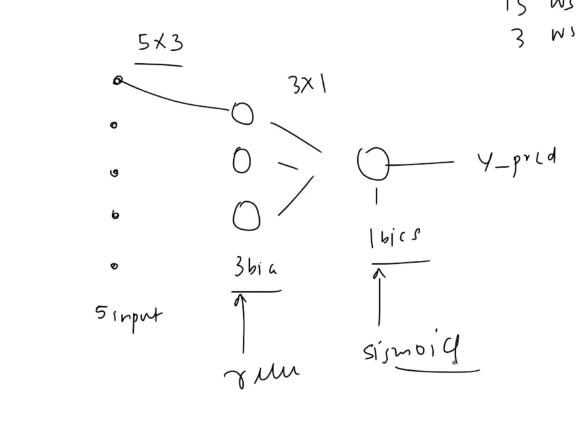

In [10]:
class ModelHiddenLayer(nn.Module):

    def __init__(self, num_features):
        super().__init__()
        
        self.linear1 = nn.Linear(num_features, 3)
        self.linear2 = nn.Linear(3,1)


        self.sigmoid = nn.Sigmoid()
        self.relu = nn.ReLU()


    def forward(self, input_features):

        out1 = self.relu(
            self.linear1(input_features)
            )

        out2 = self.sigmoid(
            self.linear2(out1)
            )
        
        return out2

In [11]:
data_ = torch.rand(10,5)

model_h = ModelHiddenLayer(data_.shape[1])
model_h(data_)

tensor([[0.5537],
        [0.5622],
        [0.5431],
        [0.5485],
        [0.5714],
        [0.5663],
        [0.5581],
        [0.5572],
        [0.5535],
        [0.5571]], grad_fn=<SigmoidBackward0>)

In [12]:
summary(model_h,input_size=(10,5))

Layer (type:depth-idx)                   Output Shape              Param #
ModelHiddenLayer                         [10, 1]                   --
├─Linear: 1-1                            [10, 3]                   18
├─ReLU: 1-2                              [10, 3]                   --
├─Linear: 1-3                            [10, 1]                   4
├─Sigmoid: 1-4                           [10, 1]                   --
Total params: 22
Trainable params: 22
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

# NN with sequential Container

In [13]:
class ModelwithSeqC (nn.Module):

    def __init__(self, num_features):
        super().__init__()
        
        self.linear1 = nn.Linear(num_features, 3)
        self.linear2 = nn.Linear(3,1)


        self.sigmoid = nn.Sigmoid()
        self.relu = nn.ReLU()

        self.network = nn.Sequential(
            nn.Linear(num_features,3),
            nn.ReLU(),
            nn.Linear(3,1),
            nn.Sigmoid()

        )


    def forward(self, input_features):

        return self.network(input_features)

In [14]:
data_ = torch.rand(10,5)

model_S = ModelHiddenLayer(data_.shape[1])
model_S(data_)

tensor([[0.4482],
        [0.4505],
        [0.4449],
        [0.4359],
        [0.4622],
        [0.4616],
        [0.4456],
        [0.4400],
        [0.4446],
        [0.4434]], grad_fn=<SigmoidBackward0>)

In [15]:
summary(model=model_S, input_size=(10,5))

Layer (type:depth-idx)                   Output Shape              Param #
ModelHiddenLayer                         [10, 1]                   --
├─Linear: 1-1                            [10, 3]                   18
├─ReLU: 1-2                              [10, 3]                   --
├─Linear: 1-3                            [10, 1]                   4
├─Sigmoid: 1-4                           [10, 1]                   --
Total params: 22
Trainable params: 22
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

# DATA LOADERS 

guide = https://www.youtube.com/watch?v=RH6DeE3bY6I&list=PLKnIA16_Rmvboy8bmDCjwNHgTaYH2puK7&index=6